In [24]:
# 使用Fashion-MNIST 数据集
%matplotlib inline
import torch
import torchvision
from torch.utils import data
from torchvision import transforms
from d2l import torch as d2l

d2l.use_svg_display()

通过框架中的内置函数将Fashion-MNIST数据集下载并读取到内存中

In [25]:
# 通过ToTensor实例将图像数据从PIL类型变换成32位浮点数格式
# 并除以255使得所有像素值均在0-1之间
trans = transforms.ToTensor()
mnist_train = torchvision.datasets.FashionMNIST(root="../data",
                                               train=True,
                                               transform=trans, # 拿到的是pytorch的tensor
                                               download=True)
mnist_test = torchvision.datasets.FashionMNIST(root="../data",
                                              train=False,
                                              transform=trans,
                                              download=True)
len(mnist_train), len(mnist_test)

(60000, 10000)

In [26]:
mnist_train[0][0].shape  # 第0个exampe，第一张图片，1是黑白图片channel，长宽28

torch.Size([1, 28, 28])

两个可视化数据集的函数

In [29]:
def get_fashion_mnist_labels(labels):
    """返回 FashionMNIST 的文本标签"""
    text_labels = [
        "T-shirt", "Trouser", "Pullover", "Dress", "Coat",
        "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
    ]
    return [text_labels[int(i)] for i in labels]

def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """显示图片"""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = d2l.plt.subplots(num_rows, num_cols, figsize=figsize)
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            # 如果是图片张量
            ax.imshow(img.numpy())
        else:
            # PIL图片
            ax.imshow(img)

几个样本的图像以及其相应的标签

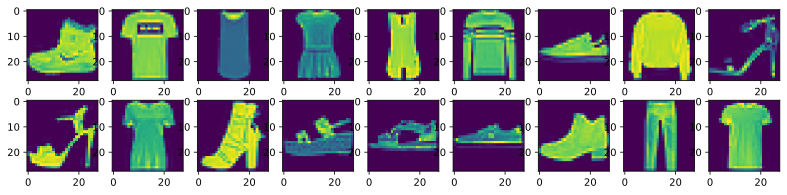

In [30]:
X, y = next(iter(data.DataLoader(mnist_train, batch_size=18)))
# reshape  宽高是28， 一共2行，每行9张，title标号为lable
# ? 有个问题 18 是 2x9 吗
show_images(X.reshape(18, 28, 28), 2, 9, titles=get_fashion_mnist_labels)

读取一小批量数据，大小为batch_size

In [31]:
batch_size = 256

def get_dataloader_workers():
    """使用4个进程来读取的数据"""
    return 4

train_iter = data.DataLoader(mnist_train, batch_size, shuffle=True, num_workers=get_dataloader_workers())

timer = d2l.Timer()
for X, y in train_iter:
    continue
f'{timer.stop():.2f} sec'

'3.98 sec'